# Clustering time-series windows by shape — `method="gmm-toeplitz"`

Some data is an **ordered, stationary signal**: a fixed-length time-series window, a trajectory, a
sensor / audio / vibration waveform, the lag features of one process. There the clustering signal
lives in **how neighbouring positions co-vary**, not in the raw coordinate values. Two AR processes
can have the *identical* per-coordinate distribution and differ only in their autocovariance — and
then:

- a **diagonal** GMM sees only per-coordinate variances → it is **blind**;
- a **full**-covariance GMM needs `N_k > d` points per component to estimate a dense `d × d` matrix →
  it is **singular** in the common "few windows, long window" regime;
- **`method="gmm-toeplitz"`** models each component covariance as an **AR(w)** process (a banded,
  positive-definite Toeplitz precision via Levinson-Durbin, `O(w)` parameters) — well-posed at
  `N_k ≪ d`, and it *improves* as the window grows.

All numbers are computed live. See [`docs/adr/001-gmm-toeplitz.md`](../docs/adr/001-gmm-toeplitz.md).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import adjusted_rand_score as ari
from sklearn.mixture import GaussianMixture

import betula_cluster

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

SPECS = ([0.8], [1.1, -0.4], [])  # AR(1) a=0.8 · AR(2) [1.1,-0.4] · white-noise control
NAMES = ["AR(1)  a=0.8", "AR(2)  [1.1, -0.4]", "white noise"]


def ar_windows(n, d, a, rng):
    """`n` length-`d` windows from a zero-mean AR(len(a)) process, rescaled to unit variance."""
    a = np.asarray(a, float)
    w = len(a)
    out = np.empty((n, d))
    for k in range(n):
        buf = np.zeros(d + 256)
        e = rng.normal(size=d + 256)
        for t in range(w, d + 256):
            buf[t] = (a * buf[t - w : t][::-1]).sum() + e[t] if w else e[t]
        win = buf[256:]
        out[k] = (win - win.mean()) / win.std()
    return out


def make_mixture(d, per, seed):
    rng = np.random.default_rng(seed)
    xs = [ar_windows(per, d, a, rng) for a in SPECS]
    y = np.concatenate([np.full(per, c) for c in range(len(SPECS))])
    return np.ascontiguousarray(np.vstack(xs), dtype=np.float64), y

## The data — three processes that look alike

A few windows from each component (length 128). To the eye they are the same standardized noise —
and their per-coordinate statistics **are** the same. The difference is only in the autocorrelation:
AR(1) is smooth and persistent, AR(2) oscillates, white noise is uncorrelated.

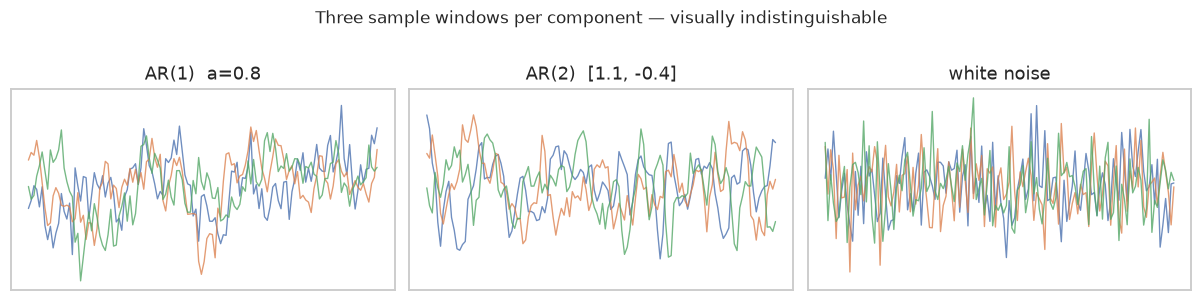

In [2]:
d = 128
X, y = make_mixture(d, per=30, seed=1)

fig, axes = plt.subplots(1, 3, figsize=(11, 2.6), sharey=True)
for c, (ax, name) in enumerate(zip(axes, NAMES)):
    for row in X[y == c][:3]:
        ax.plot(row, lw=0.9, alpha=0.8)
    ax.set(title=name, xticks=[], yticks=[])
fig.suptitle("Three sample windows per component — visually indistinguishable", y=1.03)
fig.tight_layout()
plt.show()

## The real discriminator — the autocovariance

Pool the lagged products `E[x_t · x_{t+τ}]` within each component. *This* is where the components
separate: the AR(1) autocovariance decays slowly, the AR(2) one oscillates, white noise drops to
zero at lag 1. `gmm-toeplitz` fits exactly this curve (as an AR model) per component.

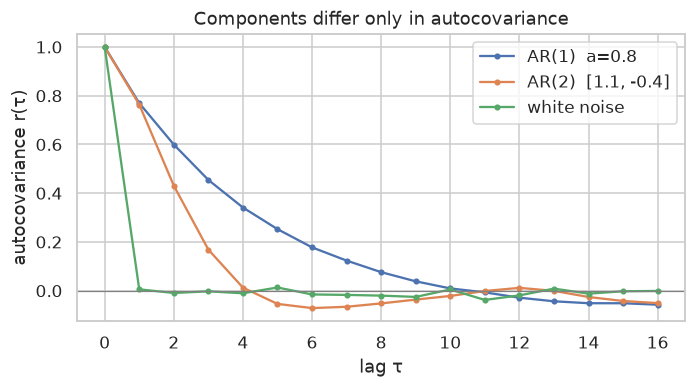

In [3]:
def autocov(rows, w=16):
    out = np.zeros(w + 1)
    for r in rows:
        for tau in range(w + 1):
            out[tau] += np.dot(r[: len(r) - tau], r[tau:]) / len(r)
    return out / len(rows)


fig, ax = plt.subplots(figsize=(6.4, 3.6))
for c, name in enumerate(NAMES):
    ax.plot(autocov(X[y == c]), "o-", ms=3, label=name)
ax.axhline(0, color="grey", lw=0.8)
ax.set(xlabel="lag τ", ylabel="autocovariance r(τ)", title="Components differ only in autocovariance")
ax.legend()
fig.tight_layout()
plt.show()

## Cluster it — only the Toeplitz head recovers the structure

The same 90 windows, `n_clusters=3`. betula's `gmm-toeplitz` is scored against the diagonal and full
GMM heads and scikit-learn's `GaussianMixture` — none of which can use the autocovariance.

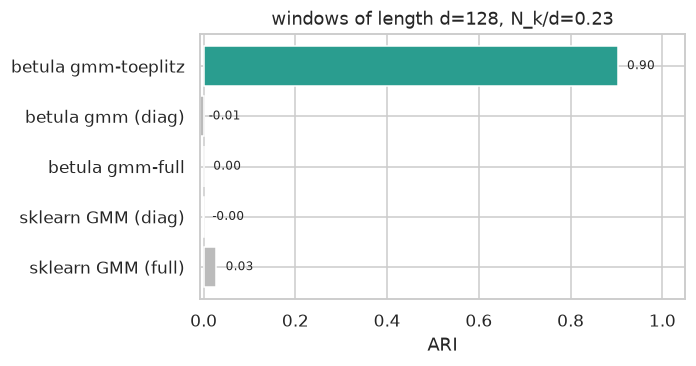

,ARI
method,
betula gmm-toeplitz,0.903
betula gmm (diag),-0.009
betula gmm-full,0.001
sklearn GMM (diag),-0.001
sklearn GMM (full),0.028


In [4]:
kw = dict(feature="spherical", threshold=0.0, seed=1)
rows = [
    ("betula gmm-toeplitz", betula_cluster.fit_predict(X, 3, method="gmm-toeplitz", **kw)),
    ("betula gmm (diag)", betula_cluster.fit_predict(X, 3, method="gmm", feature="diagonal", threshold=0.0, seed=1)),
    ("betula gmm-full", betula_cluster.fit_predict(X, 3, method="gmm-full", feature="full", threshold=0.0, seed=1)),
    ("sklearn GMM (diag)", GaussianMixture(3, covariance_type="diag", n_init=8, random_state=0).fit_predict(X)),
    ("sklearn GMM (full)", GaussianMixture(3, covariance_type="full", reg_covar=1e-3, n_init=8, random_state=0).fit_predict(X)),
]
tbl = pd.DataFrame({"method": [r[0] for r in rows], "ARI": [round(ari(y, np.asarray(r[1])), 3) for r in rows]}).set_index("method")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
colors = ["#2a9d8f"] + ["#bbb"] * 4
ax.barh(range(len(tbl)), tbl["ARI"], color=colors)
ax.set(yticks=range(len(tbl)), xlabel="ARI", xlim=(min(0, tbl["ARI"].min()), 1.05), title=f"windows of length d={d}, N_k/d={30 / d:.2f}")
ax.set_yticklabels(tbl.index)
ax.invert_yaxis()
for i, v in enumerate(tbl["ARI"]):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8)
fig.tight_layout()
plt.show()
tbl

## It gets *better* as the window grows

Longer windows push `N_k/d` down — fatal for full covariance, irrelevant for a diagonal model, and
**helpful** for `gmm-toeplitz`: more positions to pool the autocovariance from, so the AR estimate
sharpens to a perfect separation.

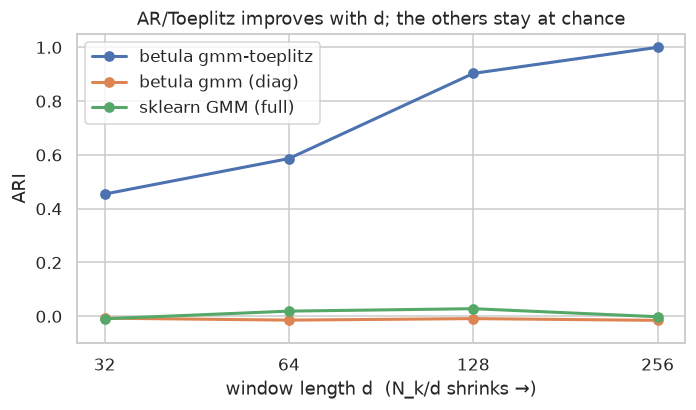

,betula gmm-toeplitz,betula gmm (diag),sklearn GMM (full)
d=32,0.454,-0.007,-0.009
d=64,0.586,-0.014,0.019
d=128,0.903,-0.009,0.028
d=256,1.000,-0.015,-0.002


In [5]:
ds = [32, 64, 128, 256]
curve = {"betula gmm-toeplitz": [], "betula gmm (diag)": [], "sklearn GMM (full)": []}
for dd in ds:
    Xd, yd = make_mixture(dd, per=30, seed=1)
    curve["betula gmm-toeplitz"].append(ari(yd, np.asarray(betula_cluster.fit_predict(Xd, 3, method="gmm-toeplitz", **kw))))
    curve["betula gmm (diag)"].append(ari(yd, np.asarray(betula_cluster.fit_predict(Xd, 3, method="gmm", feature="diagonal", threshold=0.0, seed=1))))
    curve["sklearn GMM (full)"].append(ari(yd, GaussianMixture(3, covariance_type="full", reg_covar=1e-3, n_init=8, random_state=0).fit_predict(Xd)))

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for name, vals in curve.items():
    ax.plot(ds, vals, "o-", lw=2, label=name)
ax.set(xlabel="window length d  (N_k/d shrinks →)", ylabel="ARI", title="AR/Toeplitz improves with d; the others stay at chance", ylim=(-0.1, 1.05))
ax.set_xscale("log", base=2)
ax.set_xticks(ds)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame(curve, index=[f"d={dd}" for dd in ds]).round(3)

**Takeaway.** For **ordered, stationary** signals — time-series windows, trajectories, sensor
waveforms — the neighbour correlation is the signal, and `method="gmm-toeplitz"` is the head that
models it: an AR(w) / Toeplitz precision (positive-definite by construction, `O(w)` parameters, order
by BIC) that stays well-posed exactly where diagonal is blind and full covariance is singular. Use
`feature="spherical"` or `"diagonal"`; it runs over the CF microclusters like every other head, so
it inherits betula's scale and bounded memory. It is **for ordered coordinates only** — on generic
embeddings a coordinate permutation would destroy the Toeplitz structure, so reach for `gmm` /
`gmm-full` there. See the [Usage guide](../docs/USAGE.md) and
[`docs/MATH.md`](../docs/MATH.md#toeplitz--ar-covariance-for-stationary-signals).